# OF-FF Heuristic in Multi-Switch TSN Network

This notebook demonstrates:

1. Loading a TSN network state from a JSON file.
2. Visualizing the network topology.
3. Displaying the per-link schedule table.
4. Implementing the Older-First First-Fit (OF-FF) heuristic.
5. Applying the heuristic to the network.
6. Visualizing the new schedule after defragmentation.

We will work with multiple switches, multiple ports, and end-to-end streams.


In [2]:
import json
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Rectangle

In [22]:
# Load network JSON
with open("scenario.json") as f:
    network_data = json.load(f)

# Quick check
print("Nodes:", [n['name'] for n in network_data['nodes']])
print("Streams:", [s['name'] for s in network_data['streams']])

Nodes: ['H1', 'H2', 'H3', 'S1', 'S2', 'S3']
Streams: ['Stream1', 'Stream2']


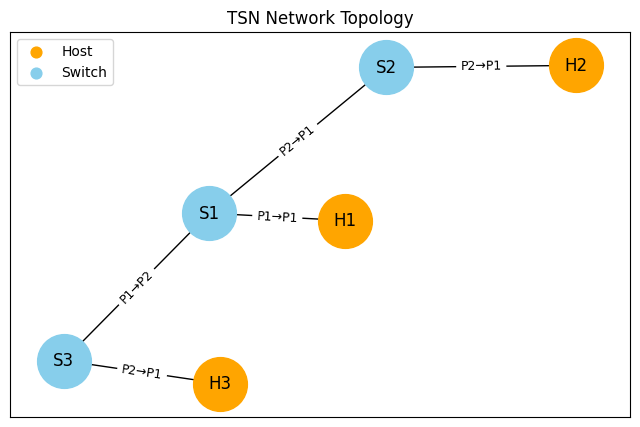

In [23]:
# Create a NetworkX graph for visualization
G = nx.DiGraph()

# Add nodes
for node in network_data['nodes']:
    G.add_node(node['name'], type=node['type'])

# Add links as edges
for link in network_data['links']:
    src = link['sourceNode']
    dst = link['destNode']
    G.add_edge(src, dst, sourcePort=link['sourcePort'], destPort=link['destPort'])

# Draw network
plt.figure(figsize=(8,5))

# Separate nodes by type
host_nodes = [n['name'] for n in network_data['nodes'] if n['type'] == 'host']
switch_nodes = [n['name'] for n in network_data['nodes'] if n['type'] == 'switch']

# Draw hosts
nx.draw_networkx_nodes(G, pos, nodelist=host_nodes, node_color='orange', node_size=1500, label='Host')
# Draw switches
nx.draw_networkx_nodes(G, pos, nodelist=switch_nodes, node_color='skyblue', node_size=1500, label='Switch')

# Draw edges and labels
nx.draw_networkx_edges(G, pos, arrows=True)
nx.draw_networkx_labels(G, pos)

edge_labels = {(e[0], e[1]): f"{G.edges[e]['sourcePort']}→{G.edges[e]['destPort']}" for e in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("TSN Network Topology")
plt.legend(scatterpoints=1, markerscale=0.2, frameon=True, loc='upper left')
plt.show()

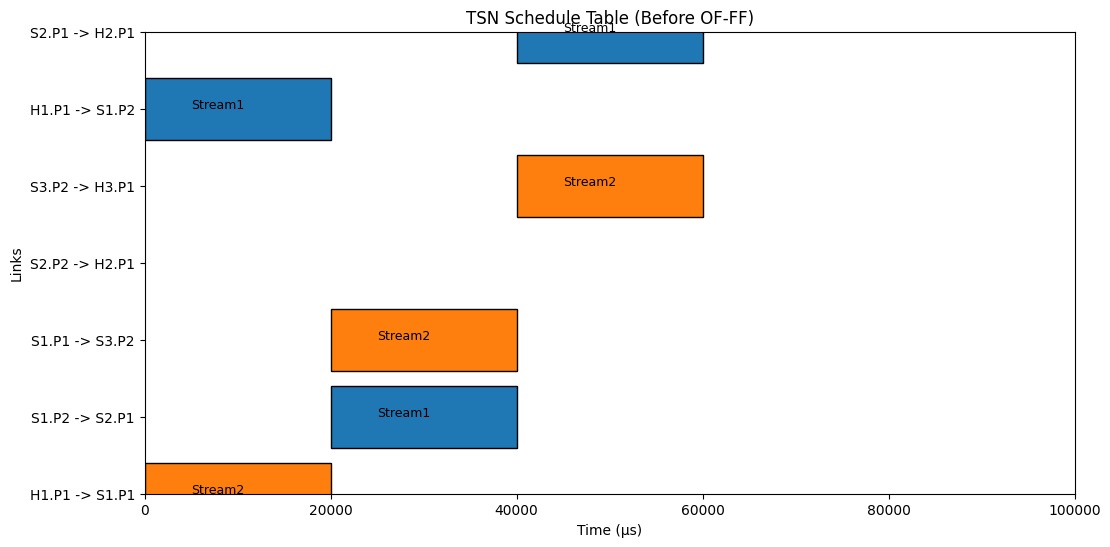

In [33]:
link_schedules_before = build_link_schedules_tsn(network_data)

fig, ax = plt.subplots(figsize=(12,6))

# y-axis: links
links = list(link_schedules_before.keys())
y_ticks = list(range(len(links)))
y_labels = links

# Create color map for streams
import matplotlib.colors as mcolors
stream_colors = {}
all_streams = [entry['stream'] for link in link_schedules_before.values() for entry in link]
colors_palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
for i, stream_name in enumerate(set(all_streams)):
    stream_colors[stream_name] = colors_palette[i % len(colors_palette)]

# Plot each stream block using per-hop TSN start
for i, link in enumerate(links):
    for entry in link_schedules_before[link]:
        rect = Rectangle(
            (entry['start'], i-0.4),  # x = start time, y = link index
            entry['duration'],        # width = duration
            0.8,                      # height of bar
            facecolor=stream_colors[entry['stream']],  # different color per stream
            edgecolor='black'
        )
        ax.add_patch(rect)
        ax.text(
            entry['start'] + entry['duration']/4, i,
            entry['stream'],
            fontsize=9, color='black'
        )

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Time (µs)")
ax.set_ylabel("Links")
ax.set_title("TSN Schedule Table (Before OF-FF)")
plt.xlim(0, 100000)
plt.show()


In [34]:
def compute_tsn_offsets(stream, network_data):
    """
    Given a stream and network data, compute the correct TSN offsets per hop.
    Updates the stream's offset to be the earliest start on the first hop.
    Returns a list of (link_name, start, duration) for each hop.
    """
    hop_schedules = []
    current_offset = stream['offset']  # start at talker
    duration = 20000  # fixed duration for visualization; could be frame size related

    for i in range(len(stream['pathLists'][0]) - 1):
        src = stream['pathLists'][0][i]
        dst = stream['pathLists'][0][i+1]
        link_name = f"{src} -> {dst}"
        
        # Find switch processing delay if dst is a switch
        dst_node = next((n for n in network_data['nodes'] if n['name'] == dst.split('.')[0]), None)
        proc_delay = dst_node['procDelay'] if dst_node and dst_node['type'] == 'switch' else 0
        
        # Find link propagation delay
        link = next((l for l in network_data['links'] 
                     if l['sourceNode'] == src.split('.')[0] and l['sourcePort'] == src.split('.')[1]
                     and l['destNode'] == dst.split('.')[0] and l['destPort'] == dst.split('.')[1]), None)
        prop_delay = link['propDelay'] if link else 0
        
        hop_schedules.append({'link_name': link_name, 'start': current_offset, 'duration': duration})
        
        # Compute offset for next hop
        current_offset = current_offset + duration + proc_delay + prop_delay

    return hop_schedules


In [35]:
def build_link_schedules_tsn(network_data):
    """
    Build per-link schedules using TSN timing for all streams.
    """
    link_schedules = {}
    for link in network_data['links']:
        link_name = f"{link['sourceNode']}.{link['sourcePort']} -> {link['destNode']}.{link['destPort']}"
        link_schedules[link_name] = []

    for stream in network_data['streams']:
        hop_schedules = compute_tsn_offsets(stream, network_data)
        for hop in hop_schedules:
            if hop['link_name'] not in link_schedules:
                link_schedules[hop['link_name']] = []
            link_schedules[hop['link_name']].append({
                'stream': stream['name'],
                'start': hop['start'],
                'duration': hop['duration']
            })
    return link_schedules


In [ ]:
def of_ff_heuristic_tsn_ff(network_data, num_reallocations=2):
    """
    TSN-correct OF-FF with true First-Fit:
    - Oldest streams first
    - Reallocate streams on links sequentially, checking conflicts
    """
    streams_sorted = sorted(network_data['streams'], key=lambda s: s['age'], reverse=True)
    to_reallocate = streams_sorted[:num_reallocations]

    # Build initial link_schedules
    link_schedules = build_link_schedules_tsn(network_data)

    for stream in to_reallocate:
        # Remove stream from link_schedules
        for link in link_schedules:
            link_schedules[link] = [e for e in link_schedules[link] if e['stream'] != stream['name']]

        # Find earliest first-fit offset for the stream path
        first_hop_offset = 0
        while True:
            hop_schedules = []
            current_offset = first_hop_offset
            conflict = False
            for i in range(len(stream['pathLists'][0]) - 1):
                src = stream['pathLists'][0][i]
                dst = stream['pathLists'][0][i+1]
                link_name = f"{src} -> {dst}"
                duration = 20000
                # Get delays
                dst_node = next((n for n in network_data['nodes'] if n['name'] == dst.split('.')[0]), None)
                proc_delay = dst_node['procDelay'] if dst_node and dst_node['type']=='switch' else 0
                link = next((l for l in network_data['links'] 
                             if l['sourceNode']==src.split('.')[0] and l['sourcePort']==src.split('.')[1]
                             and l['destNode']==dst.split('.')[0] and l['destPort']==dst.split('.')[1]), None)
                prop_delay = link['propDelay'] if link else 0

                # Check conflicts on this link
                for e in link_schedules.get(link_name, []):
                    if not (current_offset + duration <= e['start'] or current_offset >= e['start'] + e['duration']):
                        conflict = True
                        break
                hop_schedules.append({'link_name': link_name, 'start': current_offset, 'duration': duration})

                # Update offset for next hop
                current_offset = current_offset + duration + proc_delay + prop_delay
                if conflict:
                    break

            if not conflict:
                # No conflict along path, done
                break
            else:
                # Shift first hop forward (step = 1 µs for simplicity)
                first_hop_offset += 1

        # Assign final offset to stream
        stream['offset'] = first_hop_offset
        # Update link_schedules
        for hop in hop_schedules:
            if hop['link_name'] not in link_schedules:
                link_schedules[hop['link_name']] = []
            link_schedules[hop['link_name']].append({
                'stream': stream['name'],
                'start': hop['start'],
                'duration': hop['duration']
            })

    return network_data, link_schedules


In [37]:
network_data, link_schedules = of_ff_heuristic(network_data, num_reallocations=2)

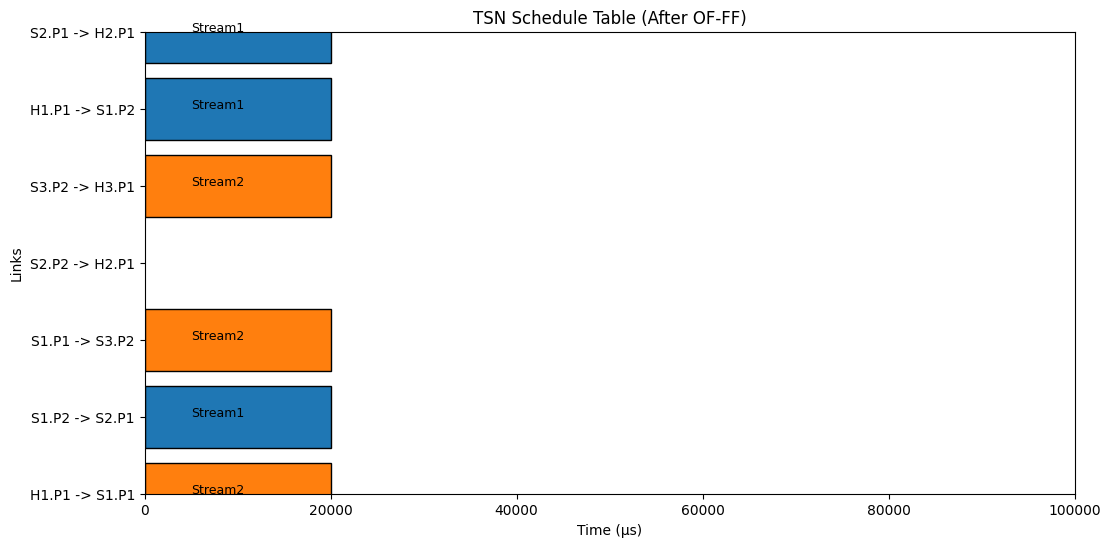

In [39]:
# TSN-Correct Schedule Table (After OF-FF)
fig, ax = plt.subplots(figsize=(12,6))

# y-axis: links
links = list(link_schedules.keys())  # link_schedules returned by of_ff_heuristic_tsn
y_ticks = list(range(len(links)))
y_labels = links

# Plot each stream block using TSN offsets
for i, link in enumerate(links):
    for entry in link_schedules[link]:
        rect = Rectangle(
            (entry['start'], i-0.4),  # x = start time
            entry['duration'],        # width = duration
            0.8,                      # height
            facecolor=stream_colors[entry['stream']],  # different color per stream
            edgecolor='black'
        )
        ax.add_patch(rect)
        ax.text(
            entry['start'] + entry['duration']/4, i,
            entry['stream'],
            fontsize=9,
            color='black'
        )

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Time (µs)")
ax.set_ylabel("Links")
ax.set_title("TSN Schedule Table (After OF-FF)")
plt.xlim(0, 100000)
plt.show()
